# 勇者傳說 — Sprite Generator (T4 GPU, Self-Contained)

Generate high-quality pixel art sprites using **SDXL + pixel-art-xl LoRA** on Colab T4.

| Model | VRAM | Speed | Use for |
|-------|------|-------|---------|
| SDXL fp16 + LoRA | ~7 GB | ~5-8s/img | Monsters, buildings, portraits |
| Flux.1-dev fp16 | ~12 GB | ~15-20s/img | Battle BGs, interiors (use env notebook) |

**Self-contained**: No repo clone needed — all code + prompts embedded in this notebook.  
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`  
**Resume**: 中斷後重跑自動跳過已完成的

## 1. Setup

In [1]:
!pip install -q "numpy<2" scipy  # fix numpy/scipy compatibility FIRST
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

# --- Mount Google Drive ---
try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

# --- Paths ---
GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- GPU check ---
import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities (Progress Tracker + VRAM)

In [2]:
class ProgressTracker:
    """Track completed items in JSON for crash-safe resume."""
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')

## 3. Prompt Data (Embedded)

In [3]:
PROMPTS = {
    "_meta": {
        "style_prefix_xl": "16-bit JRPG pixel art, Dragon Quest style, Akira Toriyama influence, vibrant colors, detailed sprite work, masterpiece quality",
        "style_suffix_pixel_xl": "pixel art, retro gaming sprite, crisp edges, limited color palette, top-down view, tileable, 2D game asset",
        "style_suffix_monster_xl": "pixel art monster sprite, detailed shading, front-facing, clean dark background, 2D JRPG enemy, single creature centered",
        "style_suffix_building_xl": "pixel art building, detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2D JRPG style",
        "style_suffix_deco_xl": "pixel art decoration, top-down view, clean background, 2D game asset, detailed",
        "style_suffix_char_xl": "pixel art character sprite, detailed shading, front-facing pose, clean solid background, 2D JRPG style",
        "negative_prompt_xl": "blurry, 3d render, photorealistic, photograph, smooth gradient, text, watermark, signature, modern, sci-fi, futuristic, complex background, busy background, multiple creatures, two creatures, pair, duplicate, group, crowd, many, low quality, worst quality, jpeg artifacts, deformed, ugly, mutation, extra limbs"
    },
    "monsters": [
        {"name": "mon_slime", "size": 192, "steps_xl": 22, "guidance_xl": 7.0, "prompt_xl": "iconic Dragon Quest blue slime, Akira Toriyama style, perfect teardrop water-droplet shape, translucent gelatinous body with light refracting through, bright cerulean blue, two round black eyes with white highlight dots, small curved happy smile, shiny glossy surface with specular highlight on top, simple cute JRPG mascot creature, no limbs no horns no ears, centered on dark background", "negative_prompt": "horns, ears, spikes, tentacles, arms, legs, feet, claws, fangs, teeth, menacing, scary, purple, multiple blobs"},
        {"name": "mon_bat", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single dark purple vampire bat creature, large outstretched leathery membranous wings with visible bone structure, soft fuzzy fur on small round body, tall pointed ears, glowing menacing red eyes, small white fangs, mid-flight hovering pose, detailed wing membrane texture"},
        {"name": "mon_goblin", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single small mischievous green goblin creature, oversized pointed ears, cunning yellow eyes with slit pupils, warty textured skin, holding crude wooden spiked club, wearing ragged brown loincloth, hunched aggressive stance, sharp teeth in wide grin, JRPG enemy"},
        {"name": "mon_snake", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single large coiled cobra serpent, iridescent green and golden yellow scales with diamond pattern, raised threatening hood spread wide, flickering red forked tongue, dripping venomous fangs, hypnotic slit-pupil eyes, muscular coiled body, detailed scale texture"},
        {"name": "mon_wolf", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single fierce snarling grey dire wolf, thick bristled silver-grey fur coat, bared sharp white fangs, glowing fierce yellow eyes, muscular powerful body in aggressive attack stance, raised hackles, bushy tail, detailed fur texture, wild and dangerous"},
        {"name": "mon_skeleton", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single undead skeleton warrior, bleached white weathered bones, visible ribcage and joints, holding rusty notched iron sword, remnants of tattered chain mail armor, eerie glowing blue-purple light in hollow eye sockets, battle-ready stance, fragments of ancient equipment"},
        {"name": "mon_spider", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single giant black widow spider, shiny black exoskeleton with subtle purple sheen, eight articulated hairy legs with sharp tips, cluster of eight glowing red eyes, large dripping venom chelicerae fangs, wispy web silk strands, terrifying arachnid creature"},
        {"name": "mon_ghost", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single floating ethereal ghost spirit, translucent white-blue wispy body fading at the bottom, hollow pitch-black empty eye sockets, wide wailing oval mouth, flowing tattered spectral robes, eerie supernatural glow, humanoid upper body dissolving into mist below, haunting otherworldly presence", "negative_prompt": "cat, animal, furry, mammal, face, portrait"},
        {"name": "mon_flower", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single carnivorous plant monster, massive venus flytrap head with rows of sharp white teeth, dark red-purple layered petals, thick thorny green stem, writhing vine tendrils, dripping digestive fluid, small angry eyes on the flower head, dangerous predatory plant creature"},
        {"name": "mon_treant", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single ancient evil treant monster, massive gnarled bark-covered body with deep wood grain texture, angry scowling face formed in the twisted wood, glowing red sap eyes, long twisted branch arms with sharp twig fingers, moss and fungus growing on body, corrupted nature spirit"},
        {"name": "mon_mushroom", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single angry mushroom creature, large bright red cap with white polka-dot spots like Amanita muscaria, thick stubby stem body with tiny legs, squinting angry eyes, puffing clouds of green toxic spores, cute but dangerous fungal monster, JRPG style"},
        {"name": "mon_lion", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single majestic fierce golden lion beast, magnificent flowing thick tawny mane, powerful muscular feline body, razor sharp extended claws, wide open roaring mouth showing large fangs, intense golden eyes, regal but deadly predator, fantasy beast"},
        {"name": "mon_scorpion", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single giant desert scorpion, menacing curved segmented tail with dripping venomous stinger raised high, massive crushing lobster-like pincers, dark brown chitinous armored exoskeleton, eight jointed legs, beady black eyes, armored arachnid predator"},
        {"name": "mon_jellyfish", "size": 192, "steps_xl": 20, "guidance_xl": 7.0, "prompt_xl": "single ethereal glowing jellyfish creature, beautiful translucent blue-violet dome bell body with internal organs visible, long trailing stinging tentacles flowing downward, mesmerizing bioluminescent sparks and light particles, deep sea magical creature, otherworldly beauty"},
        {"name": "mon_shark", "size": 192, "steps_xl": 22, "guidance_xl": 7.0, "prompt_xl": "single massive great white shark, sleek dark grey body with white underbelly, tall triangular dorsal fin, supernaturally glowing red eyes, wide gaping jaws revealing rows of razor-sharp serrated teeth, powerful streamlined predator body, oceanic terror"},
        {"name": "mon_golem", "size": 192, "steps_xl": 22, "guidance_xl": 7.0, "prompt_xl": "single towering stone golem construct, massive body made of rough grey boulders and rock slabs, glowing orange-gold magical rune inscriptions across body, huge heavy raised stone fists, ancient clay and moss between stone segments, magically animated guardian"},
        {"name": "mon_dragon_young", "size": 192, "steps_xl": 22, "guidance_xl": 7.0, "prompt_xl": "single young fire dragon, large outstretched red leathery bat-like wings, breathing stream of orange fire, emerald green overlapping scales covering body, golden yellow armored underbelly plates, sharp ivory claws and horns, fierce but youthful dragon face, powerful fantasy creature"},
        {"name": "mon_demon_soldier", "size": 192, "steps_xl": 22, "guidance_xl": 7.0, "prompt_xl": "single intimidating demon soldier, full dark spiked black iron armor with crimson trim, curved ram-like horns protruding from helmet, blazing red eyes glowing from within visor, wielding cruel jagged serrated dark sword, hellish warrior from the abyss, menacing battle stance"},
        {"name": "mon_dark_knight", "size": 192, "steps_xl": 22, "guidance_xl": 7.0, "prompt_xl": "single terrifying dark death knight, imposing full black ornate plate armor with skull motifs, haunting purple-violet glowing light from behind closed visor, wielding massive purple energy-infused greatsword, flowing tattered dark cape, undead fallen paladin, corrupted holy warrior"},
        {"name": "mon_boss_guardian", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single corrupted holy paladin boss monster, towering imposing armored figure, once-magnificent golden plate armor now cracked and stained with dark corruption spreading across surface, blazing vengeful red eyes through damaged helm, wielding enormous ornate greatsword crackling with dark energy, tattered sacred cape, fallen champion, dramatic threatening battle pose"},
        {"name": "mon_boss_elf_king", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single corrupted ancient elf king boss monster, impossibly tall regal elven figure, ornate dark thorned crown of twisted black wood, once-beautiful elven features now gaunt and corrupted with dark veins, dark parasitic vines wrapping and constricting body, wielding massive gnarled living staff pulsing with dark green energy, tattered royal robes, fallen woodland sovereign"},
        {"name": "mon_boss_ancient_tree", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single ancient corrupted world-tree boss monster, enormous gnarled trunk body as thick as a tower, deeply furrowed bark with dark rot spreading, massive twisted branch arms reaching outward with claw-like twig fingers, terrifying angry face carved into wood with glowing crimson sap leaking from eye hollows, parasitic mushrooms and dark moss covering body, apocalyptic forest guardian gone mad"},
        {"name": "mon_boss_beast_general", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single fearsome minotaur beast general boss monster, massively muscular humanoid body with powerful bull head, thick curved horns tipped with iron caps, dark spiked battle armor with tribal markings, wielding enormous double-headed battle axe, flaring nostrils with steam, blazing wrathful red eyes, war-scarred veteran beast warrior, dominant intimidating stance"},
        {"name": "mon_boss_sea_dragon", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single majestic sea dragon leviathan boss monster, long sinuous serpentine body, beautiful iridescent blue-green-teal overlapping scales, regal crown of living coral and pearls, sharp translucent fin crests along spine, powerful webbed claws, swirling water magic aura with floating water orbs, ancient ocean deity, elegant yet terrifying aquatic dragon"},
        {"name": "mon_boss_mountain_king", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single colossal mountain giant king boss monster, towering figure made of rough grey mountain stone and earth, brilliant blue crystal formations growing from shoulders and back, ancient rune carvings glowing across stone body, wielding impossibly large stone war hammer, earthquake-causing footsteps, primordial earth elemental sovereign, living mountain incarnate"},
        {"name": "mon_boss_forge_master", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single apocalyptic forge demon boss monster, massive body of flowing molten magma barely contained within cracking dark volcanic rock crust, brilliant orange-white fire visible through spreading cracks, wielding enormous burning war hammer wreathed in flames, dripping lava from joints, volcanic eruption energy, infernal blacksmith of the underworld, heat distortion aura"},
        {"name": "mon_boss_death_lord", "size": 256, "steps_xl": 28, "guidance_xl": 7.5, "prompt_xl": "single terrifying undead lich death lord boss monster, ancient skeletal king draped in flowing dark tattered purple-black necromancer robes, ornate bone crown studded with glowing purple soul gems, wielding massive dark scythe dripping with necrotic energy, orbiting floating skulls with green fire in eye sockets, dark magic aura, supreme undead overlord"},
        {"name": "mon_boss_demon_lord", "size": 256, "steps_xl": 30, "guidance_xl": 8.0, "prompt_xl": "single ultimate great demon lord final boss, impossibly massive dark winged figure dominating the frame, enormous curved ram horns wreathed in hellfire, blazing infernal eyes burning with malevolent intelligence, full ornate spiked obsidian armor with glowing red rune inscriptions, wielding colossal flaming demonic greatsword, six dark feathered wings spread wide, dark energy vortex swirling around, absolute evil incarnate, lord of the abyss, final boss of a JRPG"}
    ],
    "buildings": [
        {"name": "bld_tudor", "size": 64, "prompt_xl": "charming tudor style house, dark timber frame with white plaster walls, thick thatched straw roof, warm candlelight glowing from small windows, climbing ivy, flower boxes, chimney with wisps of smoke, cobblestone path, cozy medieval village dwelling"},
        {"name": "bld_shop", "size": 64, "prompt_xl": "bustling medieval merchant shop, ornate hanging wooden sign with carved emblem, large display window showing potions bottles and magical goods, colorful awning, warm interior glow, barrels and crates outside, weathered stone and timber construction"},
        {"name": "bld_castle", "size": 64, "prompt_xl": "imposing medieval stone castle keep, tall central tower with flying banner, Hogwarts inspired gothic architecture, arched entrance with portcullis, stained glass windows, gargoyles on corners, crenelated battlements, torch-lit entrance"},
        {"name": "bld_inn", "size": 64, "prompt_xl": "welcoming medieval inn and tavern, hand-painted wooden sign showing golden tankard, warm amber light spilling from mullioned windows, thick chimney billowing cozy smoke, heavy oak door, stone foundation, second floor with balcony, hanging lanterns"},
        {"name": "bld_church", "size": 64, "prompt_xl": "serene medieval stone church, magnificent rose stained glass window in brilliant colors, tall bell tower with bronze bell, gothic pointed arches, heavy wooden doors, surrounding graveyard visible, holy light emanating from within"},
        {"name": "bld_blacksmith", "size": 64, "prompt_xl": "busy medieval blacksmith forge, iron anvil sign hanging over entrance, thick black smoke from brick chimney, open forge area with glowing orange coals visible, weapon and armor display racks, sturdy stone walls with wooden beams, sparks flying"},
        {"name": "bld_wizard_tower", "size": 64, "prompt_xl": "mysterious wizard tower, slightly crooked tall stone spire, glowing arcane purple-blue light from round windows, swirling magical energy at the peak, astronomical instruments on balcony, Hogwarts style, covered in ancient runes, enchanted atmosphere"},
        {"name": "bld_ruins", "size": 64, "prompt_xl": "hauntingly beautiful ancient ruins, crumbling stone walls and broken arches, thick ivy and moss covering surfaces, mysterious glowing runes still visible, scattered stone rubble, wild vegetation reclaiming the structure, atmospheric mist"}
    ],
    "portraits": [
        {"name": "portrait_hero", "size": 256, "prompt_xl": "detailed JRPG character portrait, handsome young prince swordsman hero, golden circlet crown, deep crimson cape flowing behind, blue steel armor with gold shoulder pauldrons and chest emblem, bright determined eyes, heroic expression, medieval fantasy, bust shot, clean background"},
        {"name": "portrait_elf", "size": 256, "prompt_xl": "detailed JRPG character portrait, graceful elf forest ranger, long pointed ears, golden circlet, flowing green cloak, dark green leather armor, wooden bow visible, serene elegant expression, nature-attuned, bust shot, clean background"},
        {"name": "portrait_treant", "size": 256, "prompt_xl": "detailed JRPG character portrait, ancient treant sage companion, textured bark skin, crown of living leaves, dark green cape, emerald robe, wise gentle glowing green eyes, crystalline staff, nature spirit elder, bust shot, clean background"},
        {"name": "portrait_beast", "size": 256, "prompt_xl": "detailed JRPG character portrait, fierce beastman martial artist, wolf-like features with furred face, red bandana tied around forehead, orange tunic revealing muscular build, battle-ready confident grin, fiery eyes, martial arts master, bust shot, clean background"},
        {"name": "portrait_merfolk", "size": 256, "prompt_xl": "detailed JRPG character portrait, beautiful merfolk ocean priestess, iridescent blue-green scales on temples and neck, silver circlet with pearl, flowing white robe, sky blue cape, gentle serene expression, aquatic beauty, healing staff, bust shot, clean background"},
        {"name": "portrait_giant", "size": 256, "prompt_xl": "detailed JRPG character portrait, imposing giant war machine warrior, iron helmet with visor, blue-steel heavy plate armor, dark blue cape, powerful stoic expression, mechanical-enhanced features, war hammer visible, industrial strength, bust shot, clean background"},
        {"name": "portrait_dwarf", "size": 256, "prompt_xl": "detailed JRPG character portrait, stealthy dwarf shadow assassin, dark hood partially covering face, brown cloak, dark leather armor, twin daggers visible, cunning sharp-eyed expression, roguish charm, shadows clinging, bust shot, clean background"},
        {"name": "portrait_undead", "size": 256, "prompt_xl": "detailed JRPG character portrait, enigmatic undead dark sorcerer, tall pointed wizard hat, flowing violet cape, deep purple robe with arcane symbols, pale spectral skin with ethereal blue-purple glow, mysterious piercing eyes, dark magic aura, bust shot, clean background"},
        {"name": "portrait_npc_shop", "size": 256, "prompt_xl": "detailed JRPG NPC portrait, friendly medieval shopkeeper, leather apron over colorful merchant outfit, warm welcoming smile, rosy cheeks, cheerful eyes, various goods visible behind, helpful expression, bust shot, clean background"},
        {"name": "portrait_npc_quest", "size": 256, "prompt_xl": "detailed JRPG NPC portrait, wise old quest giver sage, long flowing white beard, mysterious dark blue robes with star patterns, knowing cryptic expression, ancient wisdom in eyes, scroll in hand, mystical aura, bust shot, clean background"},
        {"name": "portrait_npc_priest", "size": 256, "prompt_xl": "detailed JRPG NPC portrait, benevolent church priest, clean white and gold robes, gentle compassionate expression, golden holy symbol pendant, soft healing glow, prayer book, kind eyes, religious authority, bust shot, clean background"},
        {"name": "portrait_npc_guide", "size": 256, "prompt_xl": "detailed JRPG NPC portrait, adventurous town guide and traveler, jaunty feathered hat, colorful traveler outfit, rolled map in hand, friendly adventurous smile, worldly experienced eyes, well-traveled, bust shot, clean background"},
        {"name": "portrait_king_r1", "size": 256, "prompt_xl": "detailed JRPG king portrait, noble and wise kingdom ruler, ornate golden crown with jewels, rich royal purple and gold cape, regal bearing, greying distinguished beard, wise authoritative expression, throne room background hints, bust shot"},
        {"name": "portrait_king_r2", "size": 256, "prompt_xl": "detailed JRPG king portrait, ancient elf king of the forest realm, delicate silver crown adorned with living leaves, flowing green and silver robes, ageless ethereal beauty, pointed ears, centuries of wisdom in calm eyes, woodland sovereign, bust shot"},
        {"name": "portrait_king_r3", "size": 256, "prompt_xl": "detailed JRPG king portrait, mighty sea king, crown of living coral and pearls, deep blue and aquamarine robes, weathered sun-tanned face, commanding presence, trident scepter, ocean waves reflected in eyes, maritime sovereign, bust shot"},
        {"name": "portrait_king_r4", "size": 256, "prompt_xl": "detailed JRPG king portrait, proud beast tribe chieftain, magnificent feathered headdress, tribal war paint and tattoo markings, fierce noble expression, fanged but wise, animal skin cape, primal authority, savanna lord, bust shot"},
        {"name": "portrait_king_r5", "size": 256, "prompt_xl": "detailed JRPG king portrait, stoic ice kingdom ruler, crystalline frost crown sparkling with ice, thick white fur cape and silver armor, pale noble face, piercing cold blue eyes, breath visible in cold air, winter sovereign, bust shot"},
        {"name": "portrait_king_r6", "size": 256, "prompt_xl": "detailed JRPG king portrait, battle-hardened mountain kingdom king, heavy iron crown, thick plate armor with mountain crest, strong square jaw, battle scars across face, grizzled veteran warrior-king, respect earned through strength, bust shot"},
        {"name": "portrait_king_r7", "size": 256, "prompt_xl": "detailed JRPG king portrait, enigmatic swamp kingdom ruler, crown of ancient bleached bones and dark gems, flowing dark tattered robes, unnaturally pale skin, mysterious thin-lipped smile, knowledge of death and rebirth, unsettling wisdom, bust shot"},
        {"name": "portrait_king_r8", "size": 256, "prompt_xl": "detailed JRPG king portrait, dignified eastern emperor, ornate golden headpiece with jade ornaments, magnificent silk robes in red and gold, perfectly composed dignified calm expression, long thin beard, calligraphy brush as scepter, imperial authority, bust shot"},
        {"name": "portrait_king_r9", "size": 256, "prompt_xl": "detailed JRPG king portrait, ethereal sky kingdom ruler, magnificent crown of white feathers and gold, pristine white and gold flowing robes, serene transcendent expression, eyes reflecting clouds, slight floating aura, heavenly sovereign, bust shot"},
        {"name": "portrait_king_r10", "size": 256, "prompt_xl": "detailed JRPG king portrait, industrious forge kingdom king, practical iron crown blackened with forge soot, royal garb visible beneath leather blacksmith apron, powerfully built arms, honest sweat-stained face, proud craftsman-king, ember glow, bust shot"},
        {"name": "portrait_king_r11", "size": 256, "prompt_xl": "detailed JRPG king portrait, scholarly archmage kingdom ruler, tall pointed wizard hat embroidered with stars and moons, long flowing silver beard, arcane spectacles perched on nose, surrounded by floating books and scrolls, ancient knowledge incarnate, bust shot"},
        {"name": "portrait_king_r12", "size": 256, "prompt_xl": "detailed JRPG king portrait, tragic dark kingdom ruler under demonic influence, once-magnificent crown now cracked and corrupted with dark veins, haunted tortured eyes showing inner struggle, noble face twisted with suffering, dark corruption spreading across royal robes, pitiable fallen sovereign, bust shot"}
    ],
    "decorations": [
        {"name": "deco_tree_green", "size": 32, "prompt_xl": "lush green oak tree, dense round canopy of rich green foliage with varied leaf tones, thick gnarled brown trunk, dappled light through leaves"},
        {"name": "deco_tree_autumn", "size": 32, "prompt_xl": "beautiful autumn tree, canopy of brilliant orange red and golden yellow leaves, some leaves gently falling, warm seasonal colors, brown trunk"},
        {"name": "deco_tree_dead", "size": 32, "prompt_xl": "spooky dead leafless tree, twisted bare dark branches reaching upward, cracked dark grey bark, eerie silhouette, haunted atmosphere"},
        {"name": "deco_tree_snow", "size": 32, "prompt_xl": "snow-laden evergreen pine tree, thick white snow covering dark green branches, winter frost, icicles hanging from needles, conifer shape"},
        {"name": "deco_rock", "size": 32, "prompt_xl": "large natural stone boulder, rough grey rock surface, green moss patches and lichen growing on sides, natural erosion cracks"},
        {"name": "deco_flowers", "size": 32, "prompt_xl": "cheerful wildflower patch, mix of red poppies yellow buttercups blue cornflowers and white daisies, green stems and leaves, meadow garden"},
        {"name": "deco_well", "size": 32, "prompt_xl": "medieval village stone well, circular rough stone wall, wooden bucket hanging on rope and winch, mossy stones, clear water visible below"},
        {"name": "deco_fountain", "size": 32, "prompt_xl": "ornate stone fountain, carved stone basin with tiered water spout, sparkling water streams, mossy aged stone, town square centerpiece"}
    ]
}

for cat in ['monsters', 'buildings', 'portraits', 'decorations']:
    print(f'{cat}: {len(PROMPTS[cat])} entries')

monsters: 28 entries
buildings: 8 entries
portraits: 24 entries
decorations: 8 entries


## 4. Load SDXL Pipeline + LoRA

In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

# Check Drive cache
sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE}, {DTYPE})...')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if model_path == SDXL_HUB:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.8])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.8)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL (cuda, torch.float16)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.8)
[pipeline] Ready in 116.4s
[vram] 6.7/14.6 GB


## 5. Background Removal + Post-Processing

In [5]:
from PIL import Image

_rembg_session = None

def remove_background(image):
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception:
        print('[warn] No background removal available')
        return image.convert('RGBA')


def build_prompt(entry, meta, category):
    prompt = entry.get('prompt_xl', entry.get('prompt', ''))
    prefix = meta.get('style_prefix_xl', '')
    suffix_key = f'style_suffix_{category.rstrip("s")}_xl'
    suffix = meta.get(suffix_key, meta.get('style_suffix_pixel_xl', ''))
    if prefix:
        prompt = f'{prefix}, {prompt}'
    if suffix:
        prompt = f'{prompt}, {suffix}'
    neg = entry.get('negative_prompt', meta.get('negative_prompt_xl', ''))
    return prompt, neg


def postprocess(image, entry, category, do_rembg=True):
    target = entry.get('size', 192)
    if do_rembg:
        image = remove_background(image)
    if image.mode == 'RGBA':
        bbox = image.getbbox()
        if bbox:
            image = image.crop(bbox)
    if category == 'portraits':
        image = image.resize((target, target), Image.LANCZOS)
    else:
        w, h = image.size
        scale = min(target / w, target / h)
        nw, nh = int(w * scale), int(h * scale)
        image = image.resize((nw, nh), Image.NEAREST)
        canvas = Image.new('RGBA', (target, target), (0, 0, 0, 0))
        canvas.paste(image, ((target - nw) // 2, target - nh),
                     image if image.mode == 'RGBA' else None)
        image = canvas
    return image


def generate_one(entry, meta, category, out_dir, tracker):
    """Generate a single sprite. Returns True if generated."""
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return False

    prompt, neg = build_prompt(entry, meta, category)
    steps = entry.get('steps_xl', 30)
    guidance = entry.get('guidance_xl', 7.5)

    print(f'  [gen] {name} (512x512, {steps} steps)')
    t0 = time.time()

    result = pipe(
        prompt=prompt, negative_prompt=neg,
        width=512, height=512,
        num_inference_steps=steps, guidance_scale=guidance,
    )
    image = result.images[0]
    image = postprocess(image, entry, category)
    image.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()
    return True

## 6. Test: Generate 1 Sprite

Token indices sequence length is longer than the specified maximum sequence length for this model (136 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dots, small curved happy smile, shiny glossy surface with specular highlight on top, simple cute jrpg mascot creature, no limbs no horns no ears, centered on dark background, pixel art monster sprite, detailed shading, front - facing, clean dark background, 2 d jrpg enemy, single creature centered']


  [gen] mon_slime (512x512, 22 steps)


Token indices sequence length is longer than the specified maximum sequence length for this model (136 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dots, small curved happy smile, shiny glossy surface with specular highlight on top, simple cute jrpg mascot creature, no limbs no horns no ears, centered on dark background, pixel art monster sprite, detailed shading, front - facing, clean dark background, 2 d jrpg enemy, single creature centered']


  0%|          | 0/22 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

        saved: mon_slime.png (24 KB, 85.7s)


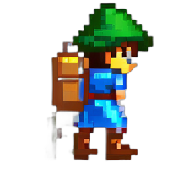

In [6]:
from IPython.display import display

meta = PROMPTS['_meta']
test_entry = PROMPTS['monsters'][0]  # slime
test_dir = OUTPUT_BASE / 'monsters'
test_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('sprites_test', OUTPUT_BASE)
generate_one(test_entry, meta, 'monsters', test_dir, tracker)

test_path = test_dir / f"{test_entry['name']}.png"
if test_path.exists():
    display(Image.open(test_path))

## 7. Generate All Monsters (28 sprites)

~5-8s per sprite on T4, total ~2-4 minutes.

In [7]:
category = 'monsters'
entries = PROMPTS[category]
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / category
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker(f'sprites_{category}', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\n{category}: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, category, out_dir, tracker)

print(f'\nDone!')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dots, small curved happy smile, shiny glossy surface with specular highlight on top, simple cute jrpg mascot creature, no limbs no horns no ears, centered on dark background, pixel art monster sprite, detailed shading, front - facing, clean dark background, 2 d jrpg enemy, single creature centered']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dots, small curved happy smile, shiny glossy surface with specular highlight on top, simple cute jrpg mascot creature, no limbs no horns no ears, centered on dark background, pixel art monster sprite, detailed shading, front - facing, clean dark background, 2 d jrpg enemy, single creature centered']



monsters: 28 total, 28 to generate

[1/28] 0/28 done
  [gen] mon_slime (512x512, 22 steps)


  0%|          | 0/22 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


        saved: mon_slime.png (50 KB, 9.2s)


...

        saved: mon_boss_death_lord.png (64 KB, 11.3s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['glowing red rune inscriptions, wielding colossal flaming demonic greatsword, six dark feathered wings spread wide, dark energy vortex swirling around, absolute evil incarnate, lord of the abyss, final boss of a jrpg, pixel art monster sprite, detailed shading, front - facing, clean dark background, 2 d jrpg enemy, single creature centered']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['glowing red rune inscriptions, wielding colossal flaming demonic greatsword, six dark feathered wings spread wide, dark energy vortex swirling around, absolute evil incarnate, lord of the abyss, final boss of a jrpg, pixel art monster sprite, detailed shading, front - facing, clean dark background, 2 d jrpg enemy, single creature centered']



[28/28] 27/28 done, ~0 min remaining
  [gen] mon_boss_demon_lord (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: mon_boss_demon_lord.png (52 KB, 12.0s)

Done!


## 8. Generate Portraits (24 sprites)

In [8]:
category = 'portraits'
entries = PROMPTS[category]
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / category
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker(f'sprites_{category}', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\n{category}: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, category, out_dir, tracker)

print(f'\nDone!')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['medieval fantasy, bust shot, clean background, pixel art, retro gaming sprite, crisp edges, limited color palette, top - down view, tileable, 2 d game asset']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['medieval fantasy, bust shot, clean background, pixel art, retro gaming sprite, crisp edges, limited color palette, top - down view, tileable, 2 d game asset']



portraits: 24 total, 24 to generate

[1/24] 0/24 done
  [gen] portrait_hero (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: portrait_hero.png (87 KB, 11.3s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['clean background, pixel art, retro gaming sprite, crisp edges, limited color palette, top - down view, tileable, 2 d game asset']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['clean background, pixel art, retro gaming sprite, crisp edges, limited color palette, top - down view, tileable, 2 d game asset']


...

        saved: portrait_king_r11.png (64 KB, 11.9s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', pitiable fallen sovereign, bust shot, pixel art, retro gaming sprite, crisp edges, limited color palette, top - down view, tileable, 2 d game asset']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', pitiable fallen sovereign, bust shot, pixel art, retro gaming sprite, crisp edges, limited color palette, top - down view, tileable, 2 d game asset']



[24/24] 23/24 done, ~0 min remaining
  [gen] portrait_king_r12 (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: portrait_king_r12.png (8 KB, 11.7s)

Done!


## 9. Generate Buildings (8 sprites)

In [9]:
category = 'buildings'
entries = PROMPTS[category]
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / category
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker(f'sprites_{category}', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\n{category}: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, category, out_dir, tracker)

print(f'\nDone!')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dwelling, pixel art building, detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2 d jrpg style']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['dwelling, pixel art building, detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2 d jrpg style']



buildings: 8 total, 8 to generate

[1/8] 0/8 done
  [gen] bld_tudor (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: bld_tudor.png (10 KB, 12.1s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['art building, detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2 d jrpg style']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['art building, detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2 d jrpg style']


...

        saved: bld_wizard_tower.png (6 KB, 12.1s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2 d jrpg style']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', detailed architecture, front elevation view, warm lighting, cozy atmosphere, clean background, 2 d jrpg style']



[8/8] 7/8 done, ~0 min remaining
  [gen] bld_ruins (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: bld_ruins.png (6 KB, 12.2s)

Done!


## 10. Generate Decorations (8 sprites)

In [10]:
category = 'decorations'
entries = PROMPTS[category]
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / category
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker(f'sprites_{category}', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\n{category}: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, category, out_dir, tracker)

print(f'\nDone!')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['down view, tileable, 2 d game asset']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['down view, tileable, 2 d game asset']



decorations: 8 total, 8 to generate

[1/8] 0/8 done
  [gen] deco_tree_green (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: deco_tree_green.png (2 KB, 11.9s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['able, 2 d game asset']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['able, 2 d game asset']


...

        saved: deco_well.png (2 KB, 13.0s)


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['tileable, 2 d game asset']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['tileable, 2 d game asset']



[8/8] 7/8 done, ~0 min remaining
  [gen] deco_fountain (512x512, 30 steps)


  0%|          | 0/30 [00:00<?, ?it/s]

        saved: deco_fountain.png (1 KB, 11.4s)

Done!


## 11. Quality Review

In [11]:
import matplotlib.pyplot as plt

for category in ['monsters', 'portraits', 'buildings', 'decorations']:
    cat_dir = OUTPUT_BASE / category
    if not cat_dir.exists():
        continue
    pngs = sorted(cat_dir.glob('*.png'))
    pngs = [p for p in pngs if not p.stem.startswith('_')]
    if not pngs:
        continue

    cols = min(6, len(pngs))
    rows = (len(pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[a] for a in axes]

    for i, p in enumerate(pngs):
        r, c = i // cols, i % cols
        axes[r][c].imshow(Image.open(p))
        axes[r][c].set_title(p.stem, fontsize=8)
        axes[r][c].axis('off')

    for i in range(len(pngs), rows * cols):
        r, c = i // cols, i % cols
        axes[r][c].axis('off')

    plt.suptitle(f'{category} ({len(pngs)} sprites)', fontsize=14)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 12. Generate Manifest + Download

In [12]:
import shutil

# Generate manifest
manifest = {}
for category in ['monsters', 'buildings', 'portraits', 'decorations', 'characters']:
    d = OUTPUT_BASE / category
    if not d.exists():
        continue
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest[category] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

# Zip + download
zip_path = '/content/sprites_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Manifest:
  monsters: 28
  buildings: 8
  portraits: 24
  decorations: 8

Zip: 2.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>